In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)

In [2]:
df = pd.read_csv("../data/raw/auto_imports.csv")

In [3]:
df.head()

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


In [4]:
column_names = [
    'symboling',
    'normalized_losses',
    'make',
    'fuel_type',
    'aspiration',
    'num_of_doors',
    'body_style',
    'drive_wheels',
    'engine_location',
    'wheel_base',
    'length',
    'width',
    'height',
    'curb_weight',
    'engine_type',
    'num_of_cylinders',
    'engine_size',
    'fuel_system',
    'bore',
    'stroke',
    'compression_ratio',
    'horsepower',
    'peak_rpm',
    'city_mpg',
    'highway_mpg',
    'price'
]

In [5]:
df = pd.read_csv("../data/raw/auto_imports.csv", header=None, na_values="?", names=column_names)

df.shape

(201, 26)

In [6]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               201 non-null    str    
 3   fuel_type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num_of_doors       199 non-null    str    
 6   body_style         201 non-null    str    
 7   drive_wheels       201 non-null    str    
 8   engine_location    201 non-null    str    
 9   wheel_base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb_weight        201 non-null    int64  
 14  engine_type        201 non-null    str    
 15  num_of_cylinders   201 non-null    str    
 16  engine_size        201 non-null    in

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
symboling,201.0,0.840796,1.254802,-2.00,0.00,1.00,2.00,3.00
normalized_losses,164.0,122.000000,35.442168,65.00,94.00,115.00,150.00,256.00
wheel_base,201.0,98.797015,6.066366,86.60,94.50,97.00,102.40,120.90
length,201.0,174.200995,12.322175,141.10,166.80,173.20,183.50,208.10
width,201.0,65.889055,2.101471,60.30,64.10,65.50,66.60,72.00
height,201.0,53.766667,2.447822,47.80,52.00,54.10,55.50,59.80
curb_weight,201.0,2555.666667,517.296727,1488.00,2169.00,2414.00,2926.00,4066.00
engine_size,201.0,126.875622,41.546834,61.00,98.00,120.00,141.00,326.00
bore,197.0,3.330711,0.270793,2.54,3.15,3.31,3.59,3.94
stroke,197.0,3.256904,0.319256,2.07,3.11,3.29,3.41,4.17


In [9]:
df.describe(include="object").T

,count,unique,top,freq
make,201,22,toyota,32
fuel_type,201,2,gas,181
aspiration,201,2,std,165
num_of_doors,199,2,four,113
body_style,201,5,sedan,94
drive_wheels,201,3,fwd,118
engine_location,201,2,front,198
engine_type,201,6,ohc,145
num_of_cylinders,201,7,four,157
fuel_system,201,8,mpfi,92


## 3. EDA

### 3.1 Missing Values

In [10]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
normalized_losses,37,18.4
bore,4,2.0
stroke,4,2.0
num_of_doors,2,1.0
horsepower,2,1.0
peak_rpm,2,1.0


### 3.2 Select Numerical values and Categorical values

In [11]:
numerical_col = df.select_dtypes(include=["int", "float"]).columns
numerical_col

Index(['symboling', 'normalized_losses', 'wheel_base', 'length', 'width',
       'height', 'curb_weight', 'engine_size', 'bore', 'stroke',
       'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
       'highway_mpg', 'price'],
      dtype='str')

In [12]:
categorical_col = df.select_dtypes(include="object").columns
categorical_col

Index(['make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style',
       'drive_wheels', 'engine_location', 'engine_type', 'num_of_cylinders',
       'fuel_system'],
      dtype='str')

### 3.3 Find relationships target variables

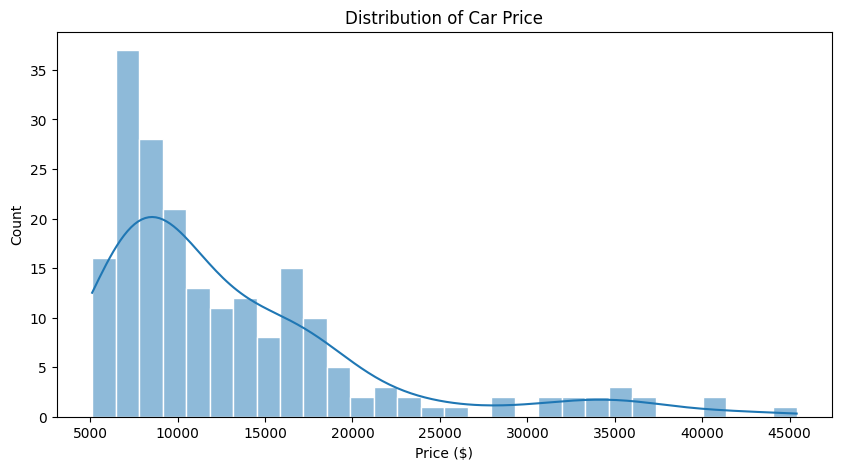

Skewness: 1.8096753390980749


In [13]:
# Target variable distribution
plt.figure(figsize=(10,5))
sns.histplot(df['price'], kde=True, bins=30, edgecolor="white")
plt.title('Distribution of Car Price')
plt.xlabel('Price ($)')
plt.savefig('../images/eda_plots/price_distribution.png')
plt.show()

print("Skewness:", df['price'].skew())

### 3.4 Numerial Feature Distribution

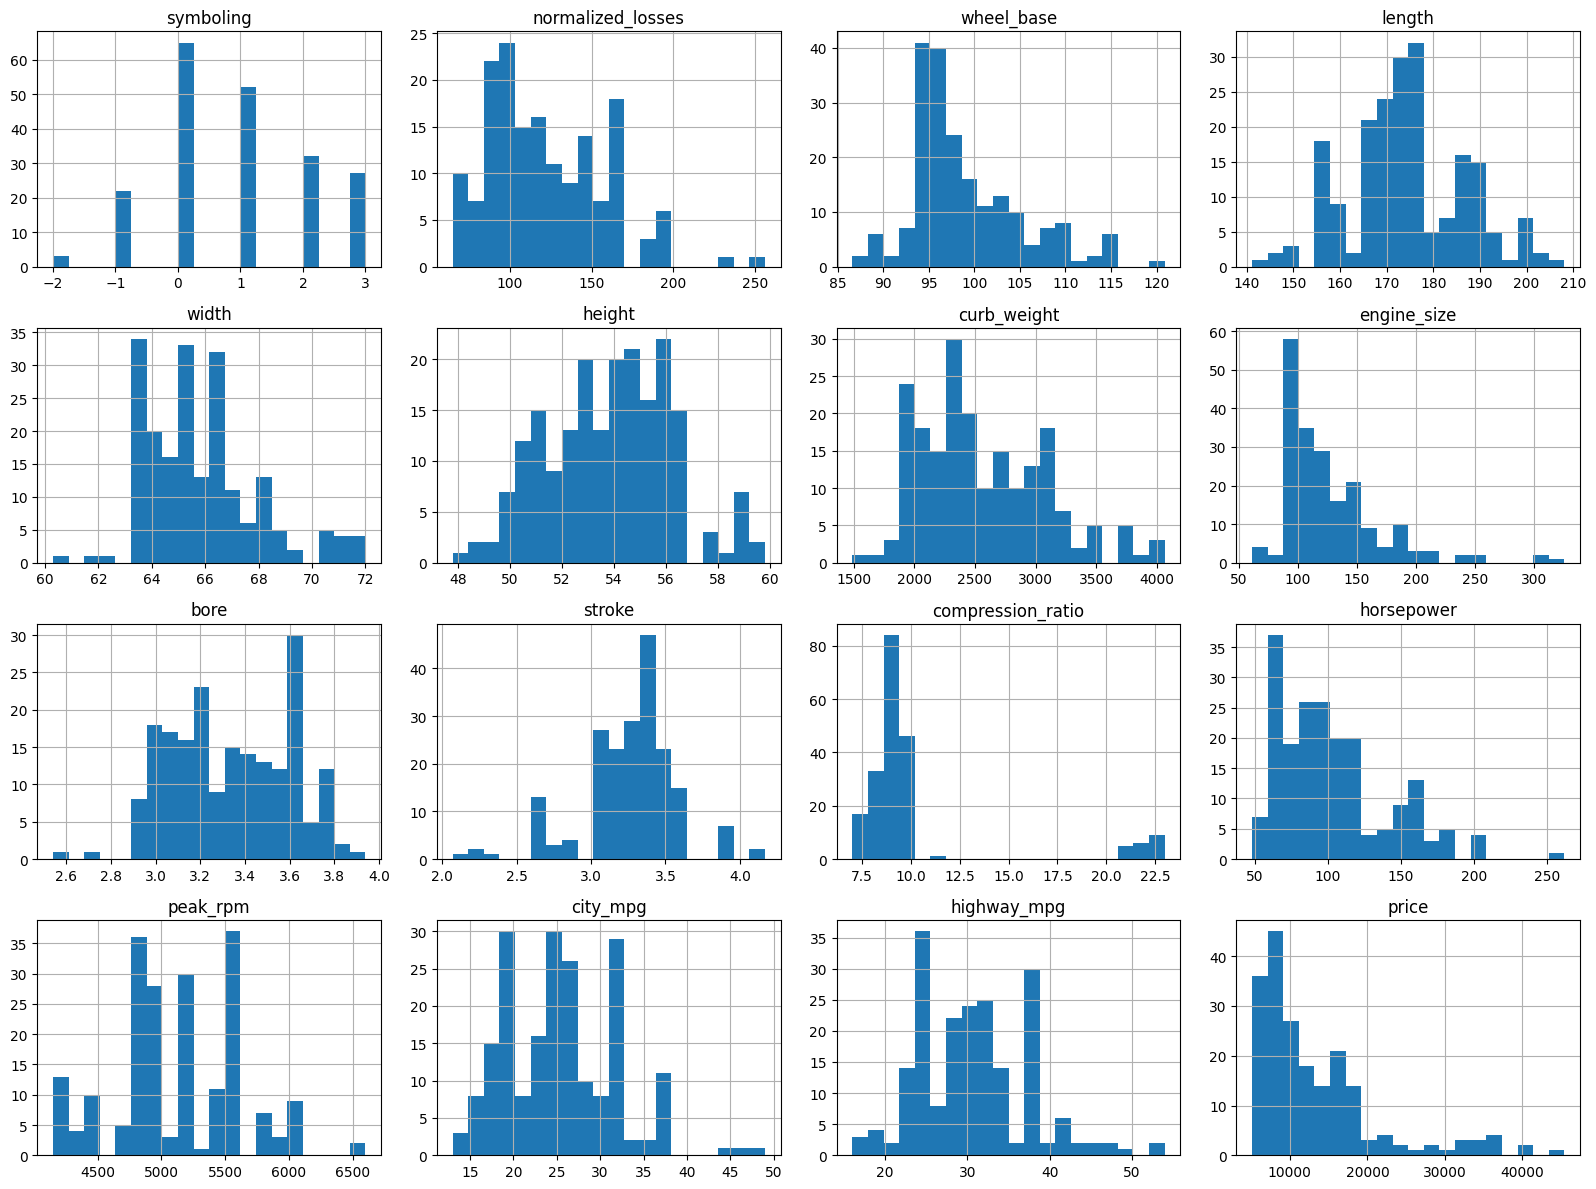

In [14]:
num = numerical_col.drop("price")
df[numerical_col].hist(bins=20, figsize=(16, 12))
plt.tight_layout()
plt.savefig(f"../images/eda_plots/numerical_feature_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.5 Categorical feature disturibution

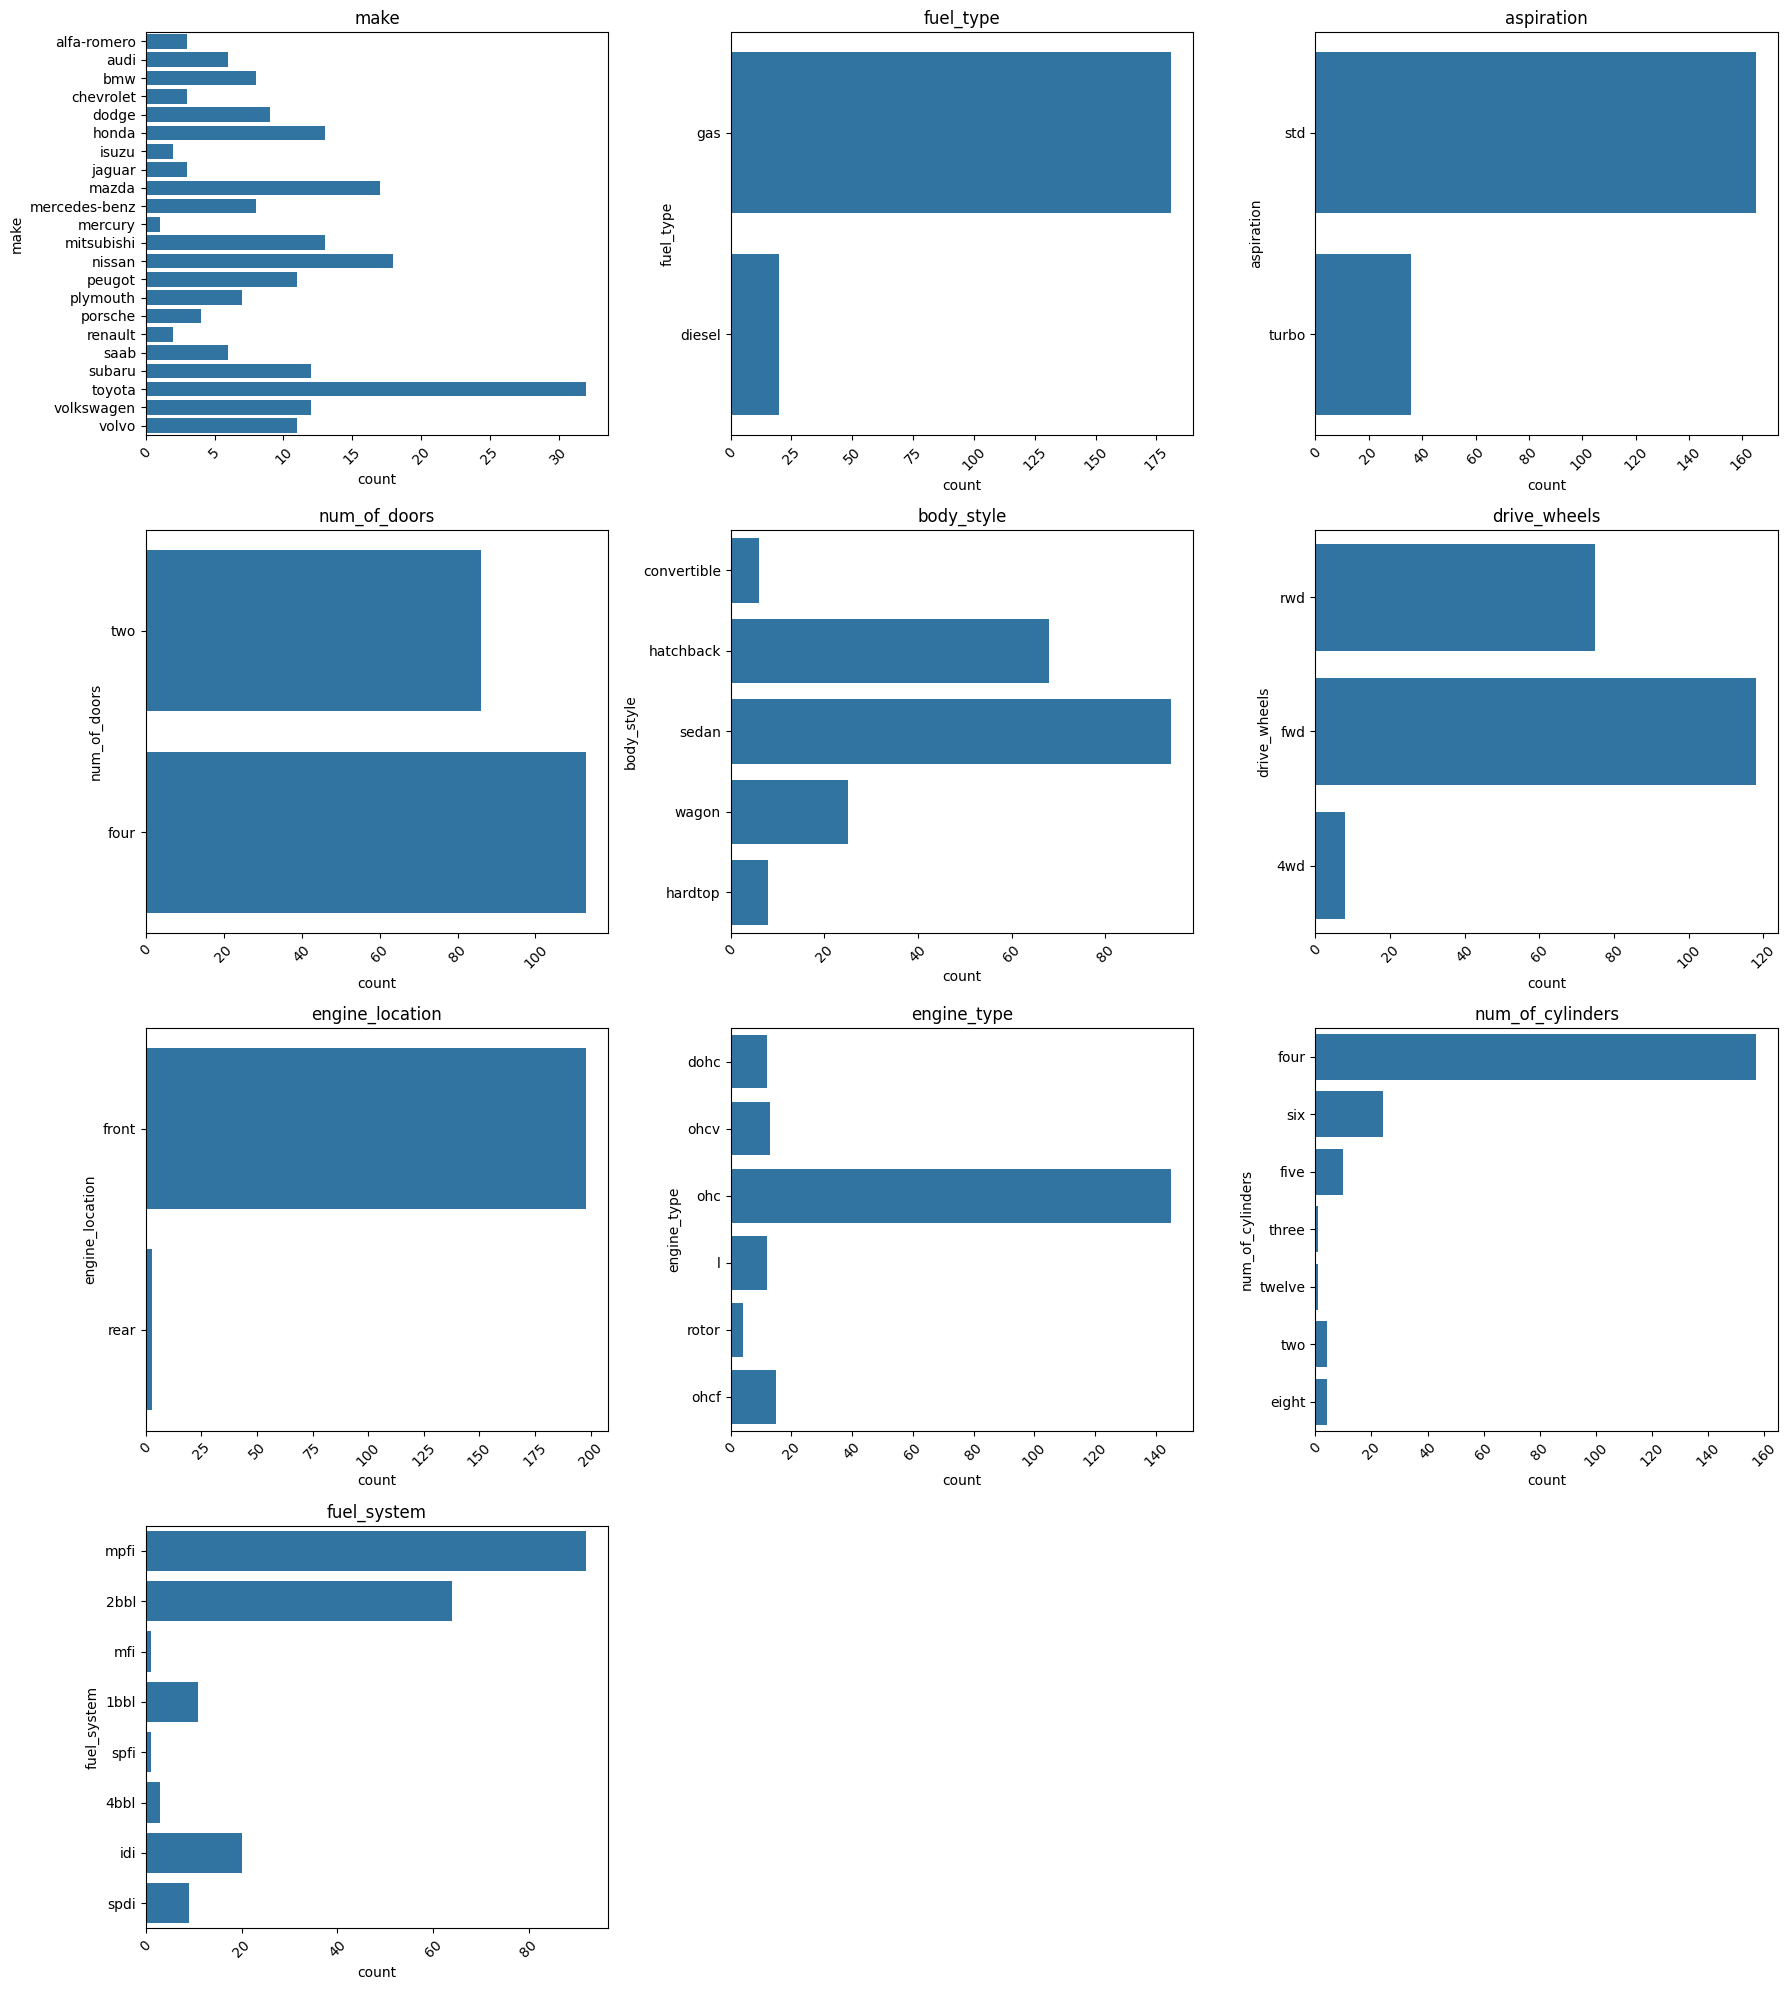

In [15]:
import math

n_cols = 3
n_rows = math.ceil(len(categorical_col) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(categorical_col, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, y=col,)
    plt.title(col)
    plt.xticks(rotation=45)

plt.savefig("../images/eda_plots/categorical_feature.png")
plt.tight_layout()
plt.show()

### 3.6 Numerical Columns vs Target Columns

#### Symboling Scale

| Symboling | Insurance Risk Rating|
|-----------:|----------------|
| -3 | Very Safe (Lowest Risk) |
| -2 | Safe |
| -1 | Slightly Safe |
| 0 | Average Risk |
| 1 | Slightly Risky |
| 2 | Risky |
| 3 | Very Risky (Highest Risk) |

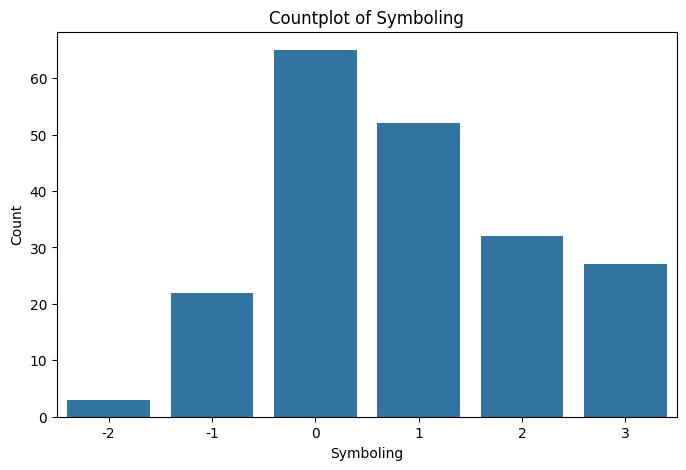

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="symboling")
plt.title("Countplot of Symboling")
plt.xlabel("Symboling")
plt.ylabel("Count")
plt.savefig("../images/eda_plots/Countplot_of_Symboling")
plt.show()

### 3.7 Correlation with price (numerical features)

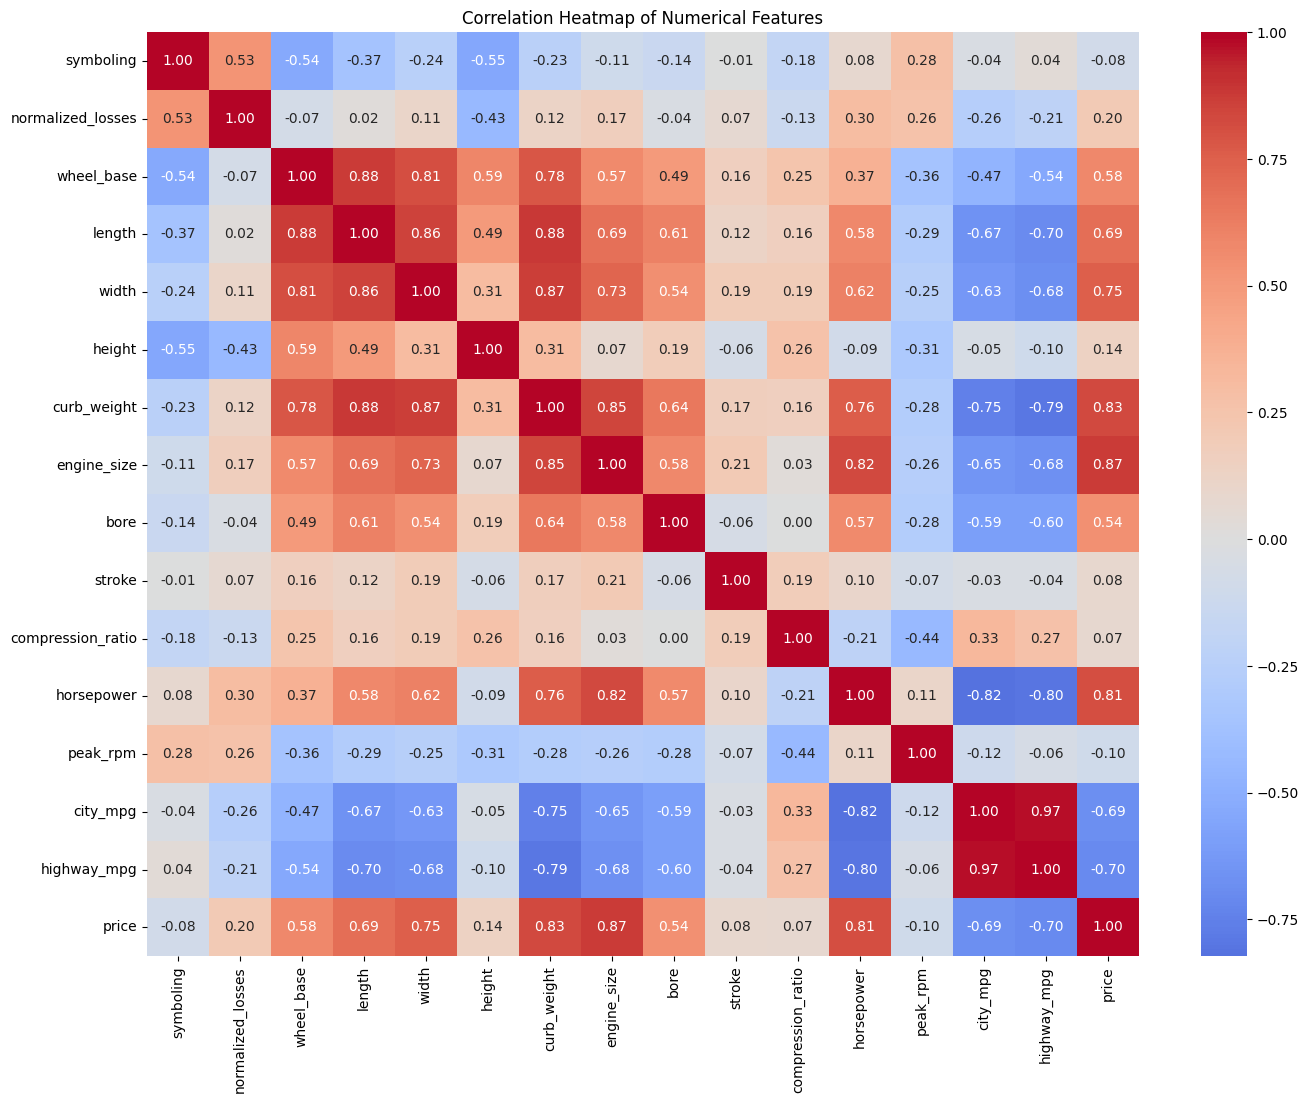

price                1.000000
engine_size          0.872335
curb_weight          0.834415
horsepower           0.810533
width                0.751265
length               0.690628
wheel_base           0.584642
bore                 0.543436
normalized_losses    0.203254
height               0.135486
stroke               0.082310
compression_ratio    0.071107
symboling           -0.082391
peak_rpm            -0.101649
city_mpg            -0.686571
highway_mpg         -0.704692
Name: price, dtype: float64


In [17]:
plt.figure(figsize=(16,12))
corr = df[numerical_col].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('../images/correlation_heatmap.png')
plt.show()

# Correlation with target specifically, sorted
print(corr['price'].sort_values(ascending=False))

Observe each scatter plot carefully.

Typical findings:

- Engine Size → Strong Positive Relationship
- Horsepower → Strong Positive Relationship
- Curb Weight → Strong Positive Relationship
- Width → Positive Relationship
- Wheel Base → Moderate Positive Relationship
- Highway MPG → Negative Relationship
- City MPG → Negative Relationship

These features are likely to become important predictors in the Machine Learning model.

### 3.8 Pairpolt - Top Numerical Features

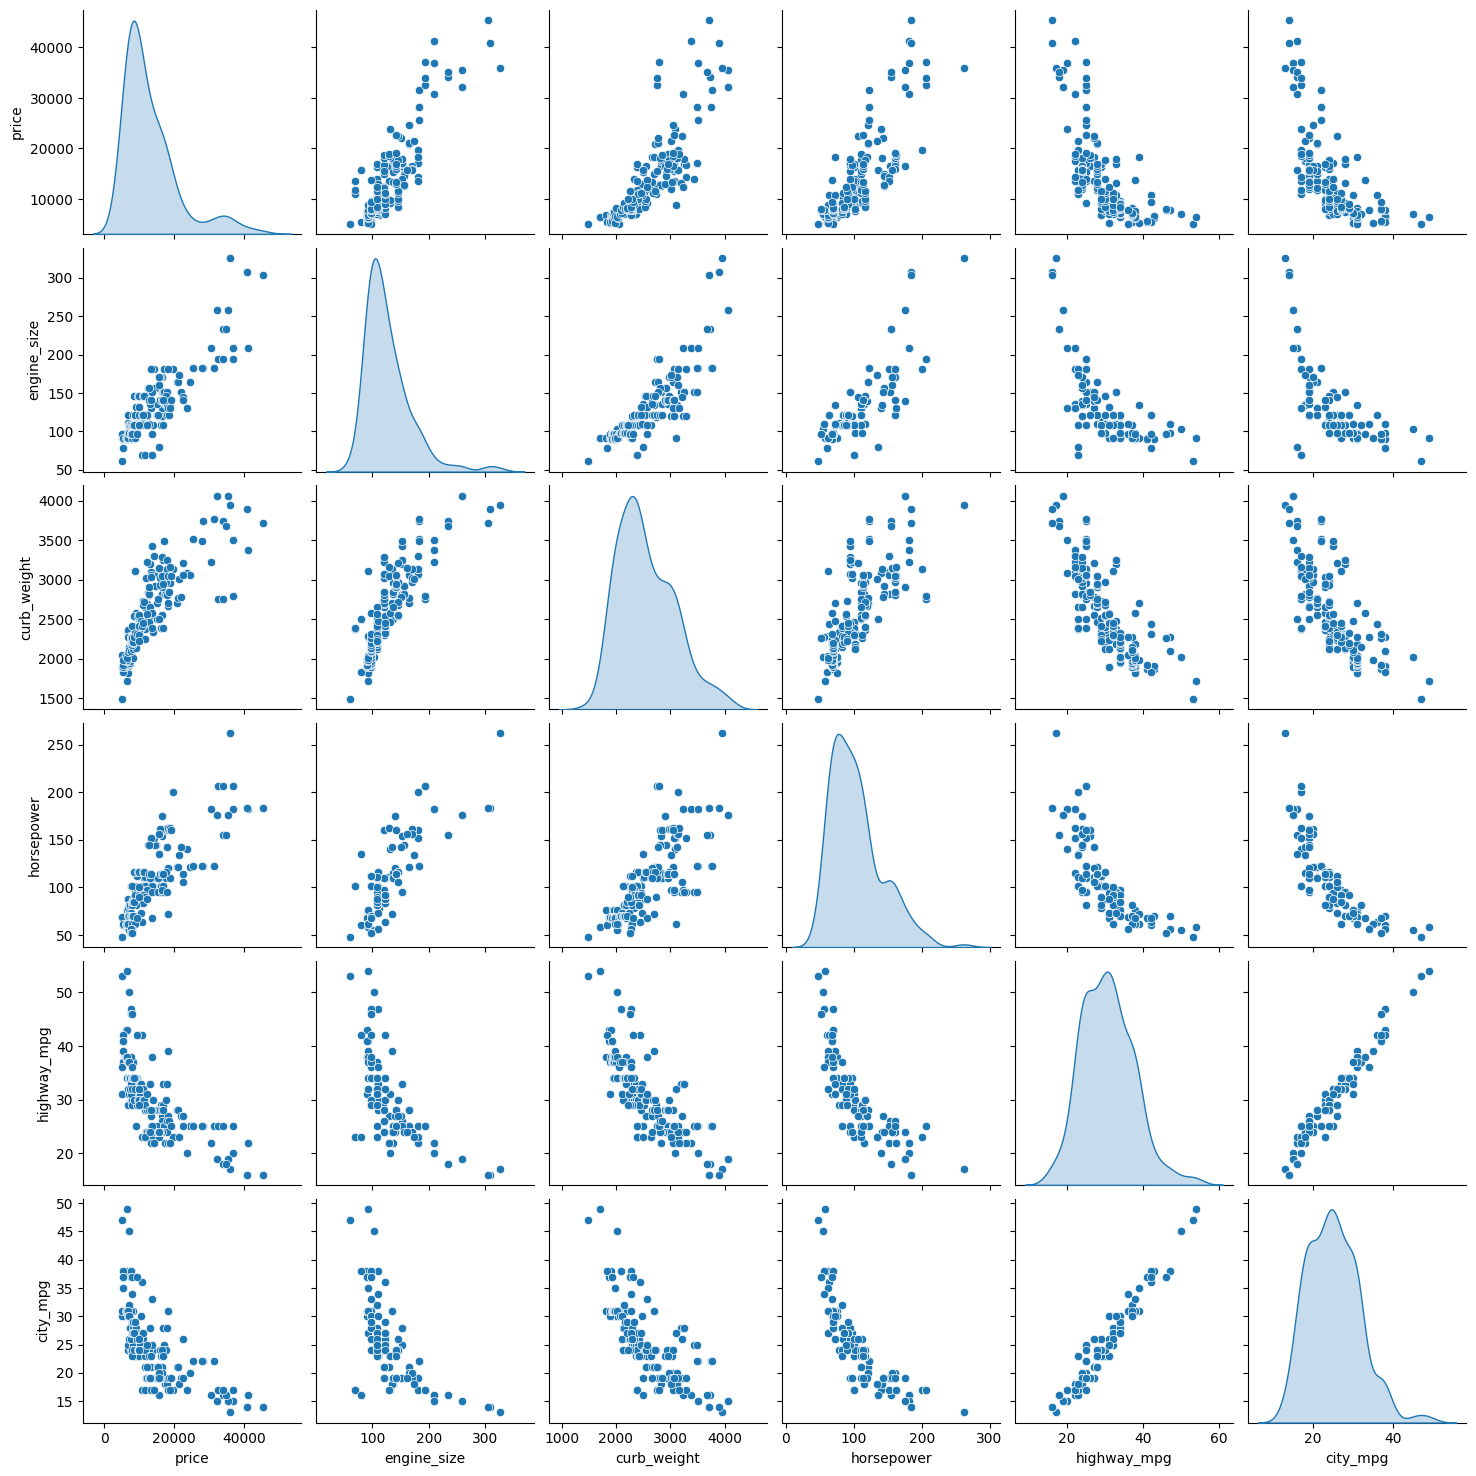

In [18]:
top_features = ['price', 'engine_size', 'curb_weight', 'horsepower', 'highway_mpg', 'city_mpg']
sns.pairplot(df[top_features], diag_kind='kde')
plt.savefig("../images/pairplot_with_top_feature.png")
plt.show()

### 3.9 Bivariate Analysis in categorical vs Price

In [19]:
for col in numerical_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + IQR*1.5
    lower_limit = Q1 - IQR*1.5

    df[col] = df[col].clip(lower_limit, upper_limit)

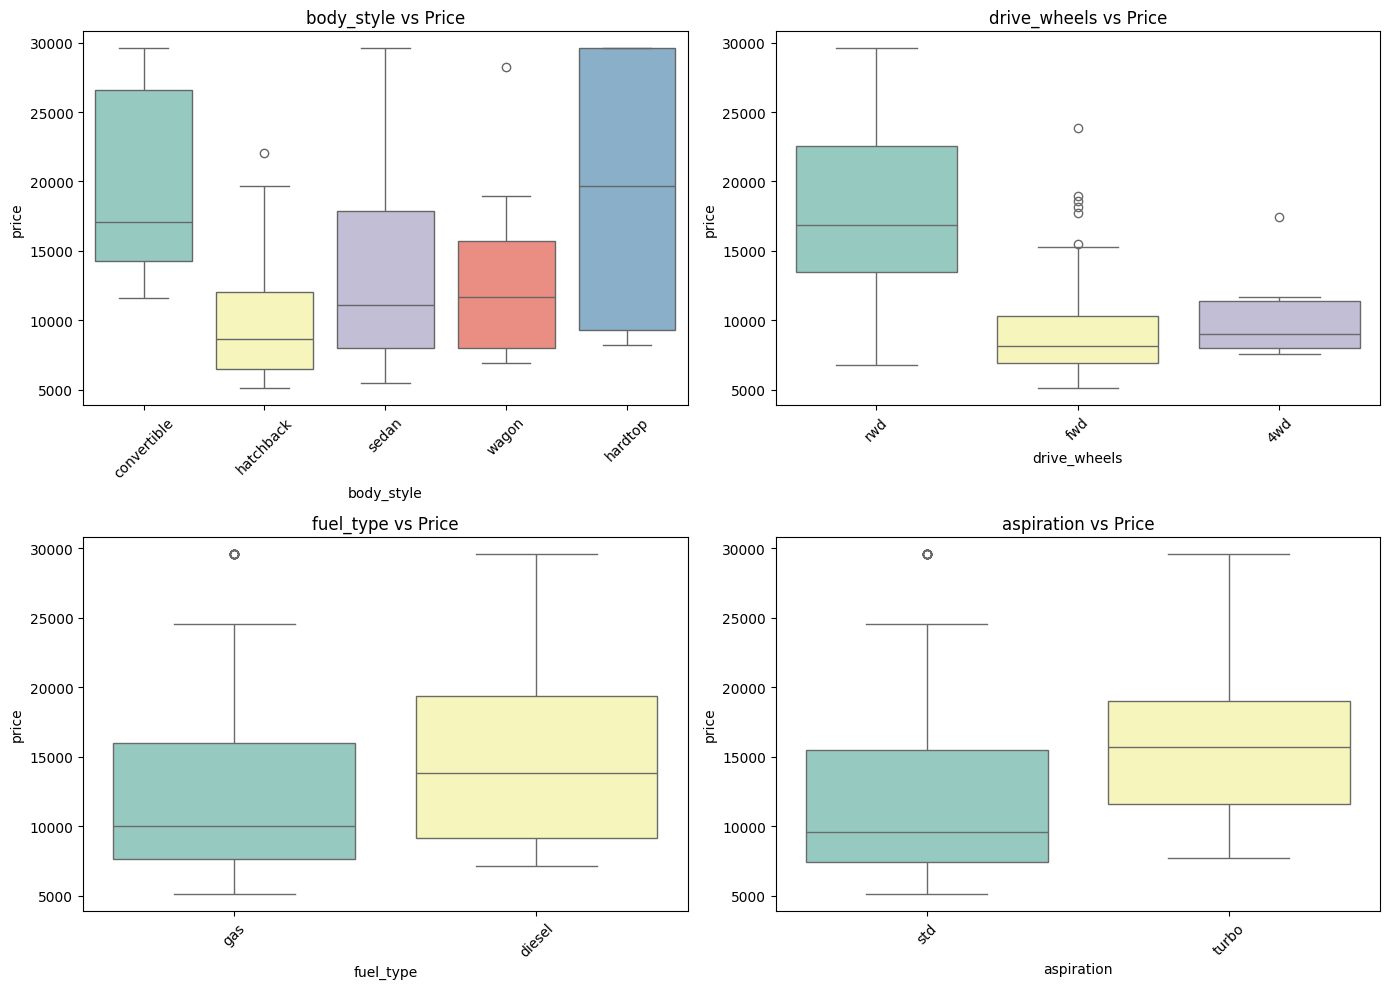

In [20]:
categorical_feature = ['body_style', 'drive_wheels', 'fuel_type', 'aspiration']

plt.figure(figsize=(14, 10))

for i, col in enumerate(categorical_feature, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, y='price', palette="Set3")
    plt.title(f'{col} vs Price')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/eda_plots/categorical_vs_price_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

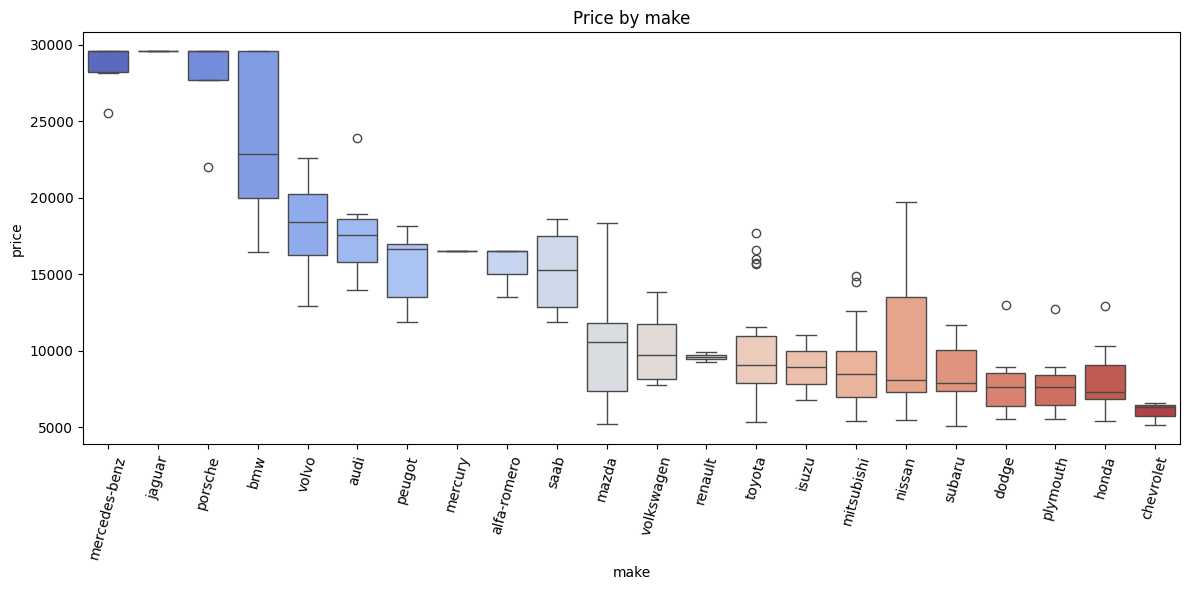

In [21]:
plt.figure(figsize=(12, 6))
order = df.groupby('make')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='make', y='price', data=df, order=order, palette='coolwarm')
plt.xticks(rotation=75)
plt.title('Price by make')
plt.tight_layout()
plt.savefig("../images/eda_plots/make_vs_price.png")
plt.show()

## 4. Data Preprossecing

### 4.1 Data Encoding

In [22]:
word_to_num = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
df['num_of_doors'] = df['num_of_doors'].map(word_to_num)
df['num_of_cylinders'] = df['num_of_cylinders'].map(word_to_num)

In [23]:
X = df.drop(columns=['price'])
y = df['price']

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['symboling', 'normalized_losses', 'num_of_doors', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'num_of_cylinders', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg']
Categorical features: ['make', 'fuel_type', 'aspiration', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'fuel_system']


In [24]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [25]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,168.8,64.1,48.8,2548.0,dohc,4,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,13495.0
1,3,NaN,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,168.8,64.1,48.8,2548.0,dohc,4,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,16500.0
2,1,NaN,alfa-romero,gas,std,2.0,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823.0,ohcv,6,152.0,mpfi,2.68,3.47,9.0,154.0,5000.0,19.0,26.0,16500.0
3,2,164.0,audi,gas,std,4.0,sedan,fwd,front,99.8,176.6,66.2,54.3,2337.0,ohc,4,109.0,mpfi,3.19,3.40,10.0,102.0,5500.0,24.0,30.0,13950.0
4,2,164.0,audi,gas,std,4.0,sedan,4wd,front,99.4,176.6,66.4,54.3,2824.0,ohc,5,136.0,mpfi,3.19,3.40,8.0,115.0,5500.0,18.0,22.0,17450.0


## 5. Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (160, 25)  Test: (41, 25)


## 6. Model Training

In [27]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=1.0, random_state=42, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf', C=10000, epsilon=500),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=6),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, random_state=42, verbosity=0)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=KFold(5, shuffle=True, random_state=42),
                                 scoring='r2')

    results.append({
        'Model': name,
        'Train R2': r2_score(y_train, y_pred_train),
        'Test R2': r2_score(y_test, y_pred_test),
        'CV R2 (mean)': cv_scores.mean(),
        'CV R2 (std)': cv_scores.std(),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Test RMSE': mean_squared_error(y_test, y_pred_test) ** 0.5
    })

results_df = pd.DataFrame(results).sort_values('CV R2 (mean)', ascending=False).reset_index(drop=True)
results_df

,Model,Train R2,Test R2,CV R2 (mean),CV R2 (std),Test MAE,Test RMSE
0,Gradient Boosting,0.997757,0.973967,0.873946,0.032596,991.264590,1434.315904
1,Ridge,0.953600,0.963160,0.855320,0.039885,1390.259767,1706.241007
2,Linear Regression,0.964904,0.968807,0.852682,0.028732,1163.470349,1570.032223
3,Random Forest,0.982243,0.956975,0.852669,0.054130,1270.775317,1843.908712
4,Lasso,0.964705,0.969785,0.849489,0.027900,1142.826363,1545.213477
5,XGBoost,0.998645,0.975985,0.840413,0.050643,891.703196,1377.585606
6,ElasticNet,0.845513,0.792955,0.805758,0.027771,2960.003464,4044.945133
7,SVR,0.969745,0.930127,0.803737,0.033284,1709.291888,2349.821115
8,Decision Tree,0.959730,0.958375,0.756589,0.125857,1203.829552,1813.673036
9,KNN,0.849628,0.748510,0.730321,0.030693,2848.090244,4458.000701


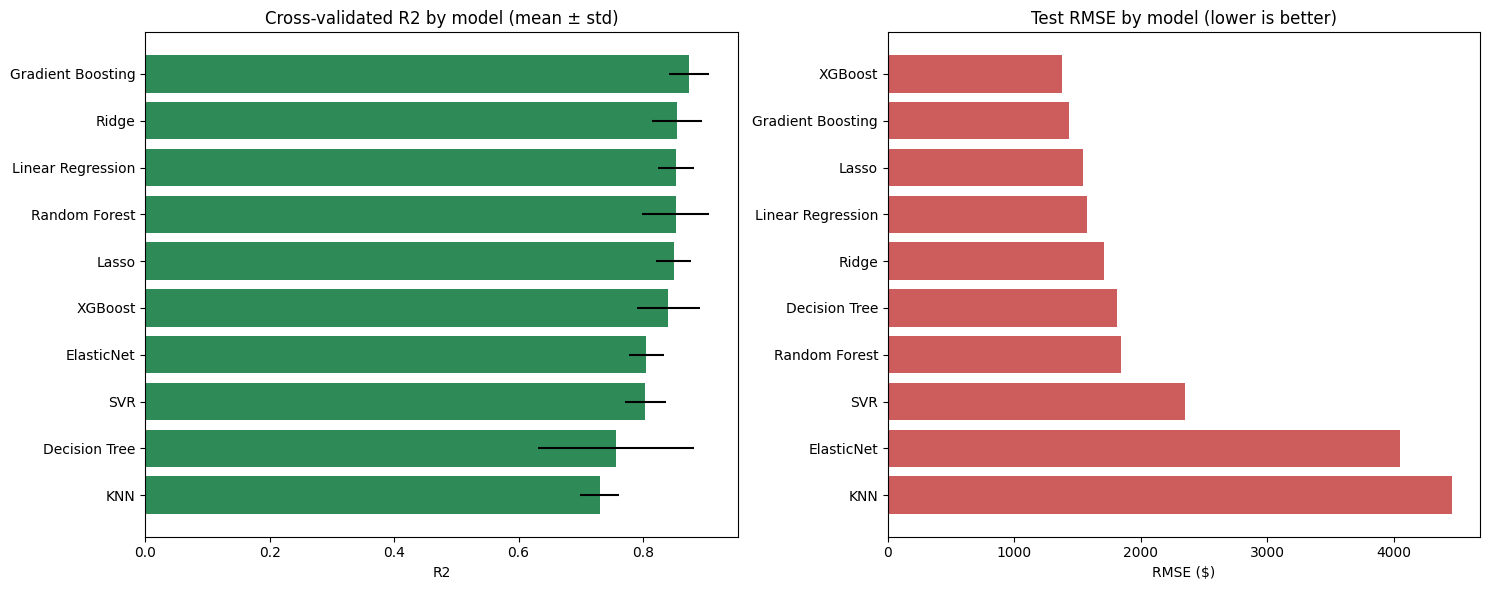

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

order = results_df.sort_values('CV R2 (mean)')
axes[0].barh(order['Model'], order['CV R2 (mean)'], xerr=order['CV R2 (std)'], color='seagreen')
axes[0].set_title('Cross-validated R2 by model (mean ± std)')
axes[0].set_xlabel('R2')

order2 = results_df.sort_values('Test RMSE', ascending=False)
axes[1].barh(order2['Model'], order2['Test RMSE'], color='indianred')
axes[1].set_title('Test RMSE by model (lower is better)')
axes[1].set_xlabel('RMSE ($)')
plt.savefig("../images/model_performance_plots/modal_comparison.png")
plt.tight_layout()
plt.show()

In [29]:
best_model_name = results_df.iloc[0]['Model']
print('Best model by CV R2:', best_model_name)
display(results_df)
results_df.to_csv("../models/model_results.csv", index=False)

Best model by CV R2: Gradient Boosting


,Model,Train R2,Test R2,CV R2 (mean),CV R2 (std),Test MAE,Test RMSE
0,Gradient Boosting,0.997757,0.973967,0.873946,0.032596,991.264590,1434.315904
1,Ridge,0.953600,0.963160,0.855320,0.039885,1390.259767,1706.241007
2,Linear Regression,0.964904,0.968807,0.852682,0.028732,1163.470349,1570.032223
3,Random Forest,0.982243,0.956975,0.852669,0.054130,1270.775317,1843.908712
4,Lasso,0.964705,0.969785,0.849489,0.027900,1142.826363,1545.213477
5,XGBoost,0.998645,0.975985,0.840413,0.050643,891.703196,1377.585606
6,ElasticNet,0.845513,0.792955,0.805758,0.027771,2960.003464,4044.945133
7,SVR,0.969745,0.930127,0.803737,0.033284,1709.291888,2349.821115
8,Decision Tree,0.959730,0.958375,0.756589,0.125857,1203.829552,1813.673036
9,KNN,0.849628,0.748510,0.730321,0.030693,2848.090244,4458.000701


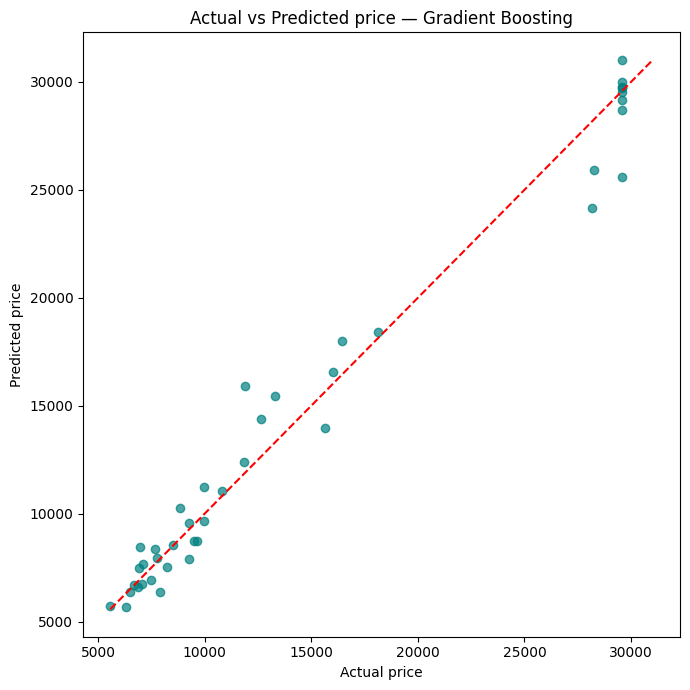

In [30]:
best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.7, color='teal')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title(f'Actual vs Predicted price — {best_model_name}')
plt.tight_layout()
plt.show()

## 7. Hyperprameter Tuning

In [31]:
param_grids = {
    'Random Forest': {'model__n_estimators': [200, 400], 'model__max_depth': [None, 8, 12],
                       'model__min_samples_leaf': [1, 2, 4]},
    'Gradient Boosting': {'model__n_estimators': [200, 400], 'model__learning_rate': [0.03, 0.05, 0.1],
                           'model__max_depth': [2, 3, 4]},
    'XGBoost': {'model__n_estimators': [200, 400], 'model__learning_rate': [0.03, 0.05, 0.1],
                'model__max_depth': [2, 3, 4]},
    'Decision Tree': {'model__max_depth': [3, 5, 7, 9], 'model__min_samples_leaf': [1, 2, 4]},
    'KNN': {'model__n_neighbors': [3, 5, 7, 9, 11]},
    'SVR': {'model__C': [1000, 10000, 50000], 'model__epsilon': [100, 500, 1000]},
    'Ridge': {'model__alpha': [0.1, 1.0, 10.0, 50.0]},
    'Lasso': {'model__alpha': [0.1, 1.0, 10.0, 50.0]},
    'ElasticNet': {'model__alpha': [0.1, 1.0, 10.0], 'model__l1_ratio': [0.2, 0.5, 0.8]},
    'Linear Regression': {}
}

pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(
    pipe,
    param_grids['Random Forest'],
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("CV R2:", grid_search.best_score_)
print("Test R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

Best Parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
CV R2: 0.8522975975828745
Test R2: 0.9543192236395087
MAE: 1331.2062280034795
RMSE: 1899.9695789086832


## 8. Model Saving

In [32]:
import pickle

with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(best_pipe, f)